<a href="https://colab.research.google.com/github/guptaankit894/AAIM/blob/main/google_colab_files/Autoencoders.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [34]:
import torch  # pytorch library
import torch.nn as nn  # neural networks
import torch.optim as optim # For selecting the optimisation function like Adam, AdamW
from torchvision import datasets, transforms # Torchvision library for built-in datasets
from torch.utils.data import DataLoader # converting and loading the dataset in batches
import matplotlib.pyplot as plt

In [35]:
transform = transforms.ToTensor()  # Transform to convert images to tensor

train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform) # Training dataset (loading the train data samples)
test_dataset  = datasets.MNIST(root='./data', train=False, transform=transform) # Test dataset (loading the test data samples)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True) # Loading the training dataset into batches with Shuffling (Shuffle=True)
test_loader  = DataLoader(test_dataset, batch_size=128) # Loading the test dataset into batches

100%|██████████| 9.91M/9.91M [00:00<00:00, 15.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 463kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.42MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 2.98MB/s]


In [36]:
class Autoencoder(nn.Module):
    def __init__(self):
        super().__init__()

        # Encoder (Linear->ReLU->Linear)
        self.encoder = nn.Sequential(
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 2)  # latent space
        )

        # Decoder (Linear->ReLU->Linear->Sigmoid)
        self.decoder = nn.Sequential(
            nn.Linear(2, 256),
            nn.ReLU(),
            nn.Linear(256, 784),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.view(-1, 784)
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

In [37]:
criterion = nn.MSELoss()

In [38]:
model = Autoencoder().to("cuda" if torch.cuda.is_available() else "cpu")
optimizer = optim.Adam(model.parameters(), lr=1e-3)

device = next(model.parameters()).device

for epoch in range(10):
    total_loss = 0

    for x, _ in train_loader:
        x = x.to(device)

        optimizer.zero_grad()
        x_recon = model(x)

        loss = criterion(x_recon, x.view(-1, 784))
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

Epoch 1, Loss: 0.0599
Epoch 2, Loss: 0.0503
Epoch 3, Loss: 0.0477
Epoch 4, Loss: 0.0462
Epoch 5, Loss: 0.0454
Epoch 6, Loss: 0.0448
Epoch 7, Loss: 0.0443
Epoch 8, Loss: 0.0439
Epoch 9, Loss: 0.0436
Epoch 10, Loss: 0.0432


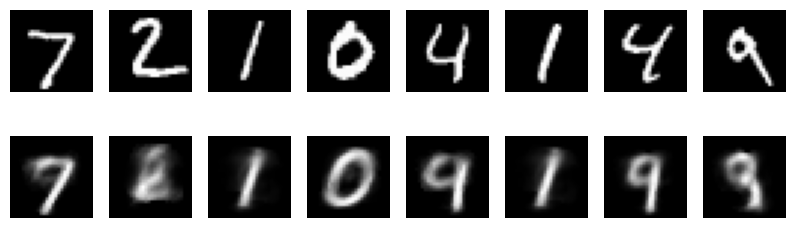

In [39]:
model.eval()
x, _ = next(iter(test_loader))
x = x.to(device)

with torch.no_grad():
    x_recon = model(x)

# Plot
fig, axes = plt.subplots(2, 8, figsize=(10, 3))

for i in range(8):
    axes[0, i].imshow(x[i].cpu().squeeze(), cmap='gray')
    axes[1, i].imshow(x_recon[i].cpu().view(28,28), cmap='gray')
    axes[0, i].axis('off')
    axes[1, i].axis('off')

plt.show()